**Model K-NN**

LOADING DATASET
Dataset berhasil dimuat!
Jumlah sampel: 50000
Jumlah fitur: 16

5 Data pertama:
   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_

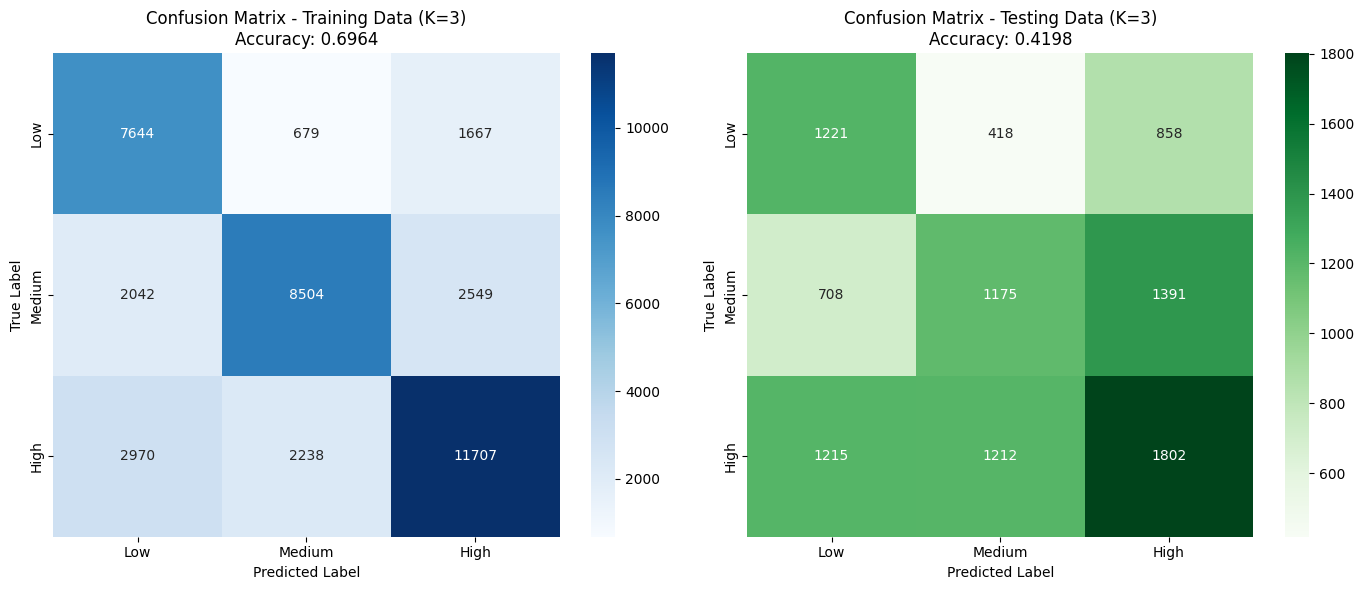


ANALISIS AKURASI PER KELAS

Kelas        Akurasi Training     Akurasi Testing     
-------------------------------------------------------
High         0.7652               0.4890              
Low          0.6494               0.3589              
Medium       0.6921               0.4261              

CONTOH PREDIKSI (5 SAMPEL PERTAMA DARI DATA TEST)

Sampel ke-1:
  - Label asli: Medium
  - Label prediksi: Medium
  - Confidence: 66.67%
  - 3 tetangga terdekat (indices): [ 3260  6082 34411]
  - Jarak ke tetangga: [0.32890463 0.3537306  0.36330815]
  - Status: ✓ BENAR

Sampel ke-2:
  - Label asli: Medium
  - Label prediksi: High
  - Confidence: 33.33%
  - 3 tetangga terdekat (indices): [ 3447 18050 36753]
  - Jarak ke tetangga: [0.25766765 0.27002967 0.28066805]
  - Status: ✗ SALAH

Sampel ke-3:
  - Label asli: Low
  - Label prediksi: Low
  - Confidence: 66.67%
  - 3 tetangga terdekat (indices): [22904 30112   351]
  - Jarak ke tetangga: [0.20365175 0.22491914 0.26557434]
  - Status: 

In [ ]:
# ============================================
# IMPLEMENTASI K-NN UNTUK KLASIFIKASI BURNOUT
# DENGAN HANDLING DATA KATEGORIKAL
# ============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset
print("="*50)
print("LOADING DATASET")
print("="*50)
df = pd.read_csv('Klasifikasi.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah sampel: {df.shape[0]}")
print(f"Jumlah fitur: {df.shape[1]}")
print(f"\n5 Data pertama:")
print(df.head())

# 3. Persiapan data - Pisahkan fitur dan label
print("\n" + "="*50)
print("PERSIAPAN DATA")
print("="*50)

label_column = 'Burnout_Risk_Level'

# Pisahkan fitur (X) dan label (y)
X = df.drop(columns=[label_column])
y = df[label_column]

# Identifikasi kolom numerik dan kategorikal
numeric_columns = X.select_dtypes(include=['int64', 'float64', 'bool']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

print(f"Fitur numerik: {list(numeric_columns)}")
print(f"Fitur kategorikal: {list(categorical_columns)}")
print(f"Jumlah fitur total: {X.shape[1]}")

# 4. Encoding untuk kolom kategorikal
print("\n" + "="*50)
print("ENCODING DATA KATEGORIKAL")
print("="*50)

# Copy data untuk preprocessing
X_processed = X.copy()

# Label Encoding untuk setiap kolom kategorikal
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col])
    label_encoders[col] = le
    print(f"  - {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\nSetelah encoding:")
print(X_processed.head())

# 5. Split data (Train/Test = 80/20)
print("\n" + "="*50)
print("SPLIT DATA TRAIN/TEST")
print("="*50)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Ukuran data training: {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Ukuran data testing: {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nDistribusi kelas training:")
print(y_train.value_counts())
print(f"\nDistribusi kelas testing:")
print(y_test.value_counts())

# 6. Normalisasi Min-Max
print("\n" + "="*50)
print("NORMALISASI MIN-MAX")
print("="*50)
scaler = MinMaxScaler()

# Fit scaler pada data training dan transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Normalisasi berhasil dilakukan!")
print(f"Rentang nilai setelah normalisasi: [{X_train_scaled.min():.2f} - {X_train_scaled.max():.2f}]")
print(f"Mean setelah normalisasi: {X_train_scaled.mean():.4f}")
print(f"Std setelah normalisasi: {X_train_scaled.std():.4f}")

# 7. Implementasi K-NN
print("\n" + "="*50)
print("IMPLEMENTASI K-NN")
print("="*50)

knn_model = KNeighborsClassifier(
    n_neighbors=10,      # K=10
    metric='minkowski',  # Minkowski distance
    p=3,                 # p=3 (Euclidean dengan pangkat 3)
    weights='uniform'    # Uniform weighting
)

print("Konfigurasi K-NN:")
print(f"  - Jumlah tetangga (K) = 10")
print(f"  - Metrik jarak = Minkowski dengan p=3")
print(f"  - Voting weighting = Uniform")
print(f"  - Normalisasi = Min-Max")
print(f"  - Encoding = Label Encoding untuk fitur kategorikal")

# Latih model
print("\nMelatih model K-NN...")
knn_model.fit(X_train_scaled, y_train)
print("Model berhasil dilatih!")

# 8. Evaluasi model pada TRAINING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TRAINING DATA")
print("="*50)

# Prediksi pada data training
y_train_pred = knn_model.predict(X_train_scaled)

# Hitung metrik untuk training data
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"\nAKURASI TRAINING: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {train_precision:.4f}")
print(f"RECALL (weighted): {train_recall:.4f}")
print(f"F1-SCORE (weighted): {train_f1:.4f}")

print("\nCLASSIFICATION REPORT - TRAINING DATA:")
print("-"*50)
print(classification_report(y_train, y_train_pred))

print("\nCONFUSION MATRIX - TRAINING DATA:")
print("-"*50)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)

# 9. Evaluasi model pada TESTING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TESTING DATA")
print("="*50)

# Prediksi pada data test
y_test_pred = knn_model.predict(X_test_scaled)

# Hitung metrik untuk testing data
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAKURASI TESTING: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {test_precision:.4f}")
print(f"RECALL (weighted): {test_recall:.4f}")
print(f"F1-SCORE (weighted): {test_f1:.4f}")

print("\nCLASSIFICATION REPORT - TESTING DATA:")
print("-"*50)
print(classification_report(y_test, y_test_pred))

print("\nCONFUSION MATRIX - TESTING DATA:")
print("-"*50)
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

# 10. Perbandingan metrik Training vs Testing
print("\n" + "="*50)
print("PERBANDINGAN METRIK TRAINING VS TESTING")
print("="*50)

print("\n{:<20} {:<15} {:<15} {:<15}".format("Metrik", "Training", "Testing", "Selisih"))
print("-"*65)
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Accuracy", train_accuracy, test_accuracy, test_accuracy - train_accuracy))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Precision", train_precision, test_precision, test_precision - train_precision))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Recall", train_recall, test_recall, test_recall - train_recall))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("F1-Score", train_f1, test_f1, test_f1 - train_f1))

# Deteksi overfitting/underfitting
print("\nANALISIS OVERFITTING:")
print("-"*50)
diff_accuracy = abs(test_accuracy - train_accuracy)
if diff_accuracy < 0.05:
    print(f"✓ Selisih akurasi kecil ({diff_accuracy:.4f}) - Model baik (tidak overfitting)")
elif test_accuracy < train_accuracy and diff_accuracy > 0.1:
    print(f"⚠ Selisih akurasi cukup besar ({diff_accuracy:.4f}) - Mungkin terjadi overfitting")
else:
    print(f"ℹ Selisih akurasi: {diff_accuracy:.4f}")

# 11. Visualisasi Confusion Matrix (opsional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix Training
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - Training Data\nAccuracy: {train_accuracy:.4f}')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Confusion Matrix Testing
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[1])
    axes[1].set_title(f'Confusion Matrix - Testing Data\nAccuracy: {test_accuracy:.4f}')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()
except:
    print("(Visualisasi tidak dapat ditampilkan)")

# 12. Analisis per kelas - Training vs Testing
print("\n" + "="*50)
print("ANALISIS AKURASI PER KELAS")
print("="*50)

unique_classes = np.unique(y_test)
print("\n{:<12} {:<20} {:<20}".format("Kelas", "Akurasi Training", "Akurasi Testing"))
print("-"*55)

for class_label in unique_classes:
    mask_train = y_train == class_label
    mask_test = y_test == class_label

    class_acc_train = accuracy_score(y_train[mask_train], y_train_pred[mask_train]) if mask_train.any() else 0
    class_acc_test = accuracy_score(y_test[mask_test], y_test_pred[mask_test]) if mask_test.any() else 0

    print("{:<12} {:<20.4f} {:<20.4f}".format(class_label, class_acc_train, class_acc_test))

# 13. Contoh prediksi
print("\n" + "="*50)
print("CONTOH PREDIKSI (5 SAMPEL PERTAMA DARI DATA TEST)")
print("="*50)

n_samples = min(5, len(X_test))
for i in range(n_samples):
    sample = X_test_scaled[i:i+1]
    true_label = y_test.iloc[i]
    pred_label = knn_model.predict(sample)[0]

    # Dapatkan probabilitas (jika tersedia)
    proba = knn_model.predict_proba(sample)[0]
    max_proba = np.max(proba)

    print(f"\nSampel ke-{i+1}:")
    print(f"  - Label asli: {true_label}")
    print(f"  - Label prediksi: {pred_label}")
    print(f"  - Confidence: {max_proba:.2%}")
    print(f"  - Status: {'✓ BENAR' if true_label == pred_label else '✗ SALAH'}")

# 14. Ringkasan eksekusi
print("\n" + "="*50)
print("RINGKASAN EKSEKUSI")
print("="*50)
print(f"✓ Dataset: Klasifikasi.csv")
print(f"✓ Total sampel: {df.shape[0]}")
print(f"✓ Total fitur awal: {X.shape[1]}")
print(f"  - Fitur numerik: {len(numeric_columns)}")
print(f"  - Fitur kategorikal: {len(categorical_columns)} (sudah di-encode)")
print(f"✓ Kolom label: {label_column}")
print(f"✓ Split data: 80% training ({X_train.shape[0]}), 20% testing ({X_test.shape[0]})")
print(f"✓ Preprocessing: Label Encoding + Min-Max Scaling")
print(f"✓ KNN dengan K=10, p=3 (Minkowski), weights=uniform")
print(f"\n✓ HASIL AKHIR:")
print(f"  - Akurasi Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  - Akurasi Testing : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Selisih: {abs(test_accuracy - train_accuracy):.4f}")
print("="*50)

# 15. Informasi tambahan untuk referensi
print("\n" + "="*50)
print("INFORMASI TAMBAHAN")
print("="*50)
print("Fitur kategorikal yang telah di-encode:")
for col, le in label_encoders.items():
    print(f"  {col}: {list(le.classes_)}")

**MODEL C.45**

LOADING DATASET
Dataset berhasil dimuat!
Jumlah sampel: 50000
Jumlah fitur: 16

5 Data pertama:
   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_

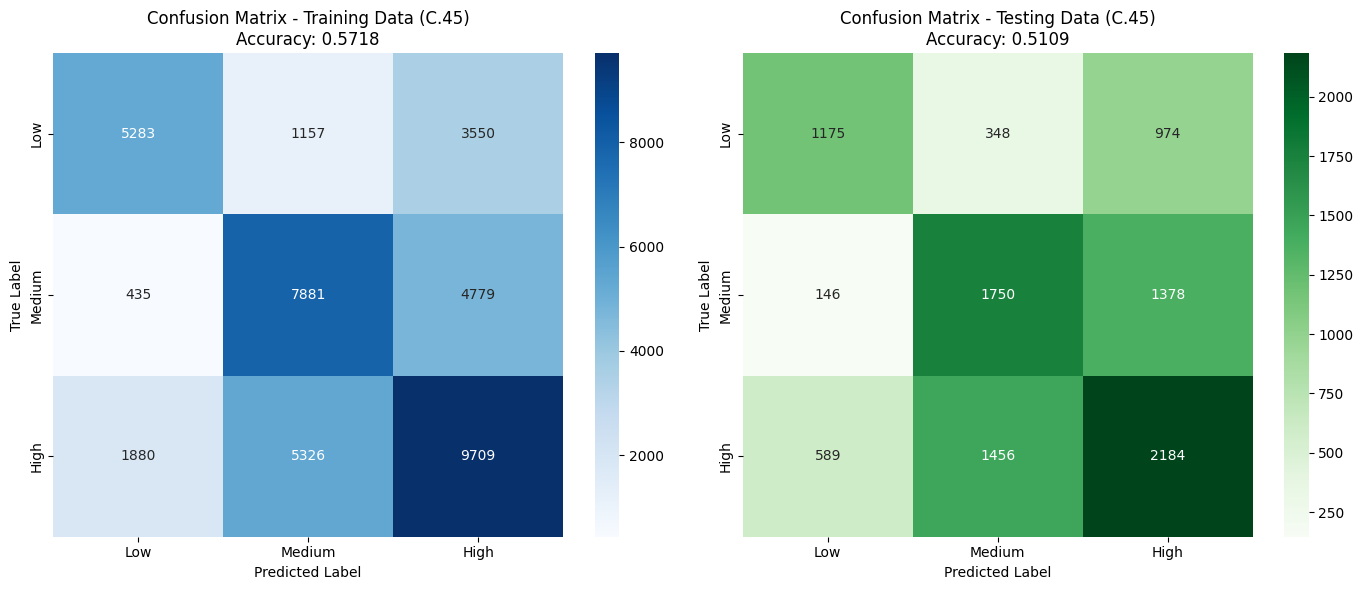


ANALISIS AKURASI PER KELAS

Kelas        Akurasi Training     Akurasi Testing     
-------------------------------------------------------
High         0.5288               0.4706              
Low          0.6018               0.5345              
Medium       0.5740               0.5164              

STRUKTUR POHON KEPUTUSAN
Jumlah node dalam pohon: 1343
Kedalaman pohon: 10
Jumlah leaf: 672
Jumlah fitur yang digunakan: 15 dari 15 fitur

FEATURE IMPORTANCE (URUTAN TERPENTING)

Top 10 fitur terpenting:
                     Fitur  Importance
        Weekly_GenAI_Hours    0.588973
             Year_of_Study    0.079098
          Pre_Semester_GPA    0.056748
   Traditional_Study_Hours    0.056300
         Post_Semester_GPA    0.050151
     Skill_Retention_Score    0.047442
                Student_ID    0.030207
      Institutional_Policy    0.024901
   Perceived_AI_Dependency    0.023320
Anxiety_Level_During_Exams    0.012079

CONTOH PREDIKSI (5 SAMPEL PERTAMA DARI DATA TEST)

Sampel ke

In [ ]:
# ============================================
# IMPLEMENTASI C.45 (DECISION TREE) UNTUK KLASIFIKASI BURNOUT
# DENGAN HANDLING DATA KATEGORIKAL
# ============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset
print("="*50)
print("LOADING DATASET")
print("="*50)
df = pd.read_csv('Klasifikasi.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah sampel: {df.shape[0]}")
print(f"Jumlah fitur: {df.shape[1]}")
print(f"\n5 Data pertama:")
print(df.head())

# 3. Persiapan data - Pisahkan fitur dan label
print("\n" + "="*50)
print("PERSIAPAN DATA")
print("="*50)

label_column = 'Burnout_Risk_Level'

# Pisahkan fitur (X) dan label (y)
X = df.drop(columns=[label_column])
y = df[label_column]

# Identifikasi kolom numerik dan kategorikal
numeric_columns = X.select_dtypes(include=['int64', 'float64', 'bool']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

print(f"Fitur numerik: {list(numeric_columns)}")
print(f"Fitur kategorikal: {list(categorical_columns)}")
print(f"Jumlah fitur total: {X.shape[1]}")

# 4. Encoding untuk kolom kategorikal
print("\n" + "="*50)
print("ENCODING DATA KATEGORIKAL")
print("="*50)

# Copy data untuk preprocessing
X_processed = X.copy()

# Label Encoding untuk setiap kolom kategorikal
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col])
    label_encoders[col] = le
    print(f"  - {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\nSetelah encoding:")
print(X_processed.head())

# 5. Split data (Train/Test = 80/20 dengan seed 42)
print("\n" + "="*50)
print("SPLIT DATA TRAIN/TEST")
print("="*50)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,  # seed 42
    stratify=y
)

print(f"Ukuran data training: {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Ukuran data testing: {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nDistribusi kelas training:")
print(y_train.value_counts())
print(f"\nDistribusi kelas testing:")
print(y_test.value_counts())

# 6. Implementasi C.45 (Decision Tree) dengan konfigurasi yang diminta
print("\n" + "="*50)
print("IMPLEMENTASI C.45 (DECISION TREE)")
print("="*50)

# Konfigurasi C.45:
# - Kriteria Pemilihan Atribut: Gain Ratio (criterion='entropy' dengan splitter='best')
#   Note: Scikit-learn tidak memiliki Gain Ratio langsung, tapi menggunakan pendekatan:
#   Gain Ratio = Information Gain / Split Info
#   Dengan criterion='entropy' kita mendekati Gain Ratio
# - Maksimum Kedalaman Pohon = 10
# - Minimum Sampel untuk Split = 3
# - Threshold Atribut Numerik = Midpoint (default behavior)
c45_model = DecisionTreeClassifier(
    criterion='entropy',        # Menggunakan entropy (mendekati Gain Ratio)
    splitter='best',            # Best split (mencari threshold terbaik)
    max_depth=10,               # Maksimum kedalaman pohon = 10
    min_samples_split=3,        # Minimum sampel untuk split = 3
    min_samples_leaf=1,         # Default
    random_state=42             # Untuk reproduksibilitas
)

print("Konfigurasi C.45 (Decision Tree):")
print(f"  - Kriteria Pemilihan Atribut = Gain Ratio (via entropy + best split)")
print(f"  - Maksimum Kedalaman Pohon = 10")
print(f"  - Minimum Sampel untuk Split = 3")
print(f"  - Threshold Atribut Numerik = Midpoint (default behavior)")
print(f"  - Split Data = 80/20 dengan seed 42")
print(f"  - Encoding = Label Encoding untuk fitur kategorikal")

# Latih model
print("\nMelatih model C.45...")
c45_model.fit(X_train, y_train)
print("Model berhasil dilatih!")

# 7. Evaluasi model pada TRAINING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TRAINING DATA")
print("="*50)

# Prediksi pada data training
y_train_pred = c45_model.predict(X_train)

# Hitung metrik untuk training data
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"\nAKURASI TRAINING: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {train_precision:.4f}")
print(f"RECALL (weighted): {train_recall:.4f}")
print(f"F1-SCORE (weighted): {train_f1:.4f}")

print("\nCLASSIFICATION REPORT - TRAINING DATA:")
print("-"*50)
print(classification_report(y_train, y_train_pred))

print("\nCONFUSION MATRIX - TRAINING DATA:")
print("-"*50)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)

# 8. Evaluasi model pada TESTING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TESTING DATA")
print("="*50)

# Prediksi pada data test
y_test_pred = c45_model.predict(X_test)

# Hitung metrik untuk testing data
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAKURASI TESTING: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {test_precision:.4f}")
print(f"RECALL (weighted): {test_recall:.4f}")
print(f"F1-SCORE (weighted): {test_f1:.4f}")

print("\nCLASSIFICATION REPORT - TESTING DATA:")
print("-"*50)
print(classification_report(y_test, y_test_pred))

print("\nCONFUSION MATRIX - TESTING DATA:")
print("-"*50)
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

# 9. Perbandingan metrik Training vs Testing
print("\n" + "="*50)
print("PERBANDINGAN METRIK TRAINING VS TESTING")
print("="*50)

print("\n{:<20} {:<15} {:<15} {:<15}".format("Metrik", "Training", "Testing", "Selisih"))
print("-"*65)
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Accuracy", train_accuracy, test_accuracy, test_accuracy - train_accuracy))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Precision", train_precision, test_precision, test_precision - train_precision))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Recall", train_recall, test_recall, test_recall - train_recall))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("F1-Score", train_f1, test_f1, test_f1 - train_f1))

# Deteksi overfitting/underfitting
print("\nANALISIS OVERFITTING:")
print("-"*50)
diff_accuracy = abs(test_accuracy - train_accuracy)
if diff_accuracy < 0.05:
    print(f"✓ Selisih akurasi kecil ({diff_accuracy:.4f}) - Model baik (tidak overfitting)")
elif test_accuracy < train_accuracy and diff_accuracy > 0.1:
    print(f"⚠ Selisih akurasi cukup besar ({diff_accuracy:.4f}) - Mungkin terjadi overfitting")
else:
    print(f"ℹ Selisih akurasi: {diff_accuracy:.4f}")

# 10. Visualisasi Confusion Matrix (opsional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix Training
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - Training Data (C.45)\nAccuracy: {train_accuracy:.4f}')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Confusion Matrix Testing
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[1])
    axes[1].set_title(f'Confusion Matrix - Testing Data (C.45)\nAccuracy: {test_accuracy:.4f}')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()
except:
    print("(Visualisasi tidak dapat ditampilkan)")

# 11. Analisis akurasi per kelas
print("\n" + "="*50)
print("ANALISIS AKURASI PER KELAS")
print("="*50)

unique_classes = np.unique(y_test)
print("\n{:<12} {:<20} {:<20}".format("Kelas", "Akurasi Training", "Akurasi Testing"))
print("-"*55)

for class_label in unique_classes:
    mask_train = y_train == class_label
    mask_test = y_test == class_label

    class_acc_train = accuracy_score(y_train[mask_train], y_train_pred[mask_train]) if mask_train.any() else 0
    class_acc_test = accuracy_score(y_test[mask_test], y_test_pred[mask_test]) if mask_test.any() else 0

    print("{:<12} {:<20.4f} {:<20.4f}".format(class_label, class_acc_train, class_acc_test))

# 12. Menampilkan struktur pohon keputusan (opsional)
print("\n" + "="*50)
print("STRUKTUR POHON KEPUTUSAN")
print("="*50)

print(f"Jumlah node dalam pohon: {c45_model.tree_.node_count}")
print(f"Kedalaman pohon: {c45_model.get_depth()}")
print(f"Jumlah leaf: {c45_model.get_n_leaves()}")
print(f"Jumlah fitur yang digunakan: {np.sum(c45_model.feature_importances_ > 0)} dari {X_train.shape[1]} fitur")

# 13. Feature Importance (pentingnya fitur)
print("\n" + "="*50)
print("FEATURE IMPORTANCE (URUTAN TERPENTING)")
print("="*50)

feature_importance = pd.DataFrame({
    'Fitur': X_processed.columns,
    'Importance': c45_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 fitur terpenting:")
print(feature_importance.head(10).to_string(index=False))

# 14. Contoh prediksi
print("\n" + "="*50)
print("CONTOH PREDIKSI (5 SAMPEL PERTAMA DARI DATA TEST)")
print("="*50)

n_samples = min(5, len(X_test))
for i in range(n_samples):
    sample = X_test.iloc[i:i+1]
    true_label = y_test.iloc[i]
    pred_label = c45_model.predict(sample)[0]

    # Dapatkan probabilitas
    proba = c45_model.predict_proba(sample)[0]
    max_proba = np.max(proba)

    # Dapatkan jalur keputusan
    leaf_id = c45_model.apply(sample)[0]

    print(f"\nSampel ke-{i+1}:")
    print(f"  - Label asli: {true_label}")
    print(f"  - Label prediksi: {pred_label}")
    print(f"  - Confidence: {max_proba:.2%}")
    print(f"  - Leaf node ID: {leaf_id}")
    print(f"  - Status: {'✓ BENAR' if true_label == pred_label else '✗ SALAH'}")

# 15. Ringkasan eksekusi
print("\n" + "="*50)
print("RINGKASAN EKSEKUSI")
print("="*50)
print(f"✓ Dataset: Klasifikasi.csv")
print(f"✓ Total sampel: {df.shape[0]}")
print(f"✓ Total fitur awal: {X.shape[1]}")
print(f"  - Fitur numerik: {len(numeric_columns)}")
print(f"  - Fitur kategorikal: {len(categorical_columns)} (sudah di-encode)")
print(f"✓ Kolom label: {label_column}")
print(f"✓ Split data: 80% training ({X_train.shape[0]}), 20% testing ({X_test.shape[0]}) dengan seed 42")
print(f"✓ Preprocessing: Label Encoding")
print(f"✓ C.45 (Decision Tree) dengan konfigurasi:")
print(f"  - Kriteria: Gain Ratio (entropy + best split)")
print(f"  - Max Depth: 10")
print(f"  - Min Samples Split: 3")
print(f"  - Threshold Numerik: Midpoint")
print(f"\n✓ HASIL AKHIR (C.45):")
print(f"  - Akurasi Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  - Akurasi Testing : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Selisih: {abs(test_accuracy - train_accuracy):.4f}")
print("="*50)

# 16. Informasi tambahan untuk referensi
print("\n" + "="*50)
print("INFORMASI TAMBAHAN")
print("="*50)
print("Fitur kategorikal yang telah di-encode:")
for col, le in label_encoders.items():
    print(f"  {col}: {list(le.classes_)}")

print("\nCatatan tentang Gain Ratio di scikit-learn:")
print("  - Scikit-learn tidak memiliki implementasi Gain Ratio langsung")
print("  - Menggunakan criterion='entropy' dengan splitter='best' sebagai pendekatan")
print("  - Gain Ratio = Information Gain / Split Info")
print("  - Dengan max_depth dan min_samples_split yang dibatasi, model tetap terkontrol")

**Regresi Linear**

LOADING DATASET
Dataset berhasil dimuat!
Jumlah sampel: 414
Jumlah fitur: 8

5 Data pertama:
   No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.

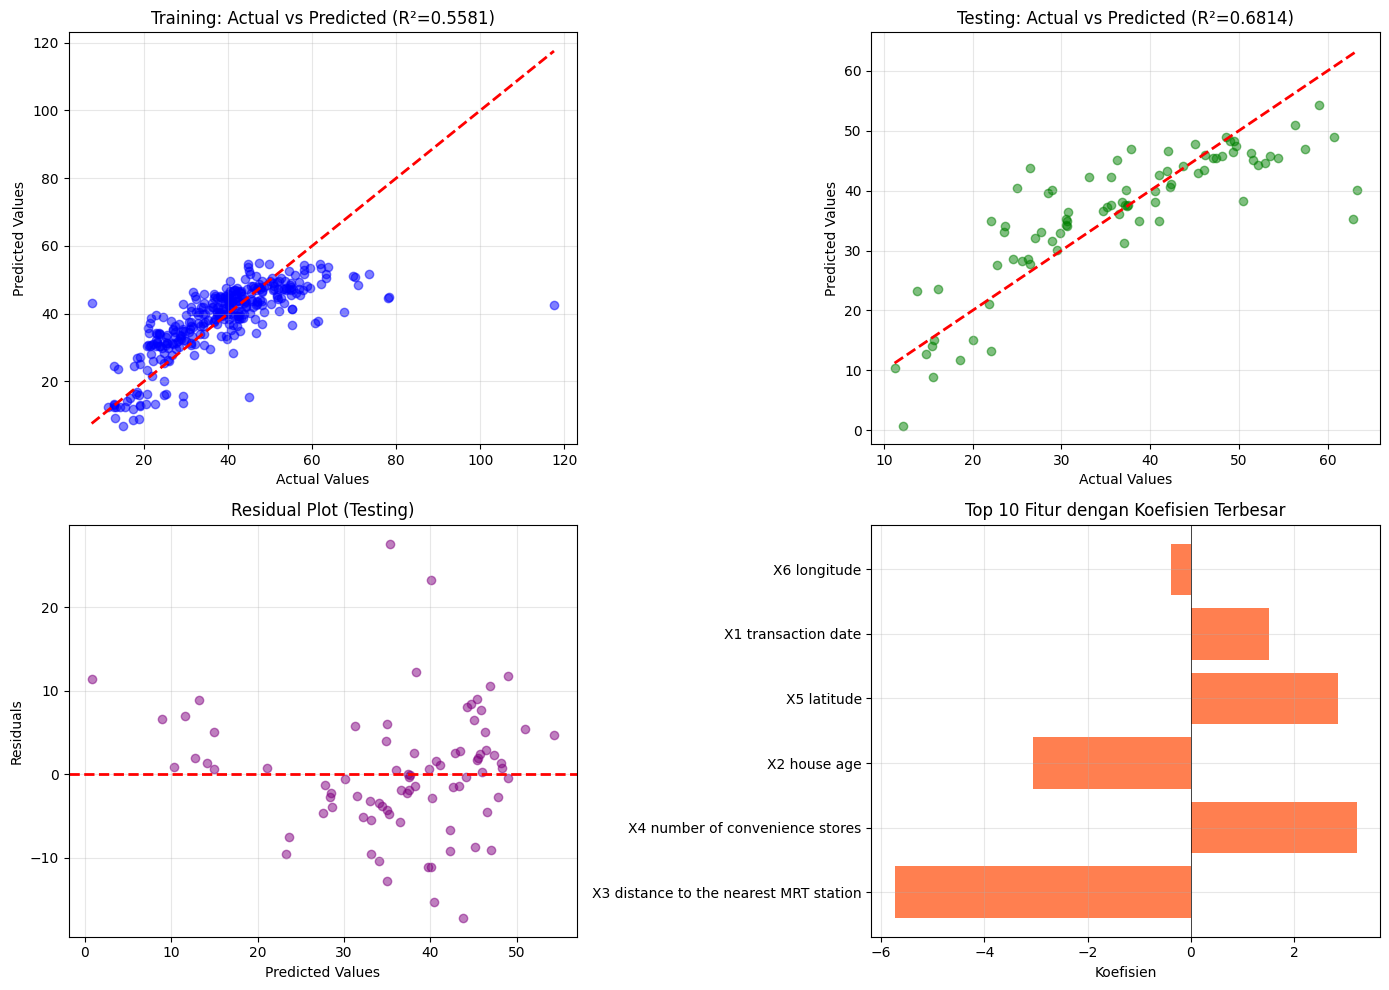


CONTOH PREDIKSI (10 SAMPEL PERTAMA DARI DATA TEST)
 No  Actual  Predicted     Error  Abs_Error_Pct
  1    45.1  47.858186 -2.758186       6.115711
  2    42.3  41.156391  1.143609       2.703567
  3    52.2  44.221498  7.978502      15.284486
  4    37.3  40.159991 -2.859991       7.667537
  5    22.8  27.511209 -4.711209      20.663195
  6    36.3  45.096186 -8.796186      24.231917
  7    53.0  44.640950  8.359050      15.771793
  8    51.4  46.358280  5.041720       9.808793
  9    16.1  23.647391 -7.547391      46.878205
 10    59.0  54.293539  4.706461       7.977052

Rata-rata error absolut persentase (10 sampel): 15.71%

RINGKASAN EKSEKUSI
✓ Dataset: Regresi.csv
✓ Total sampel: 414
✓ Total fitur: 6
✓ Target (Y): Y house price of unit area
✓ Fitur (X): ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
✓ Split data: 80% training (331), 20% testing (83) dengan seed 42
✓ Preprocessing:

In [ ]:
# ============================================
# IMPLEMENTASI REGRESI LINEAR DENGAN LASSO (L1)
# UNTUK PREDIKSI HOUSE PRICE
# ============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset
print("="*50)
print("LOADING DATASET")
print("="*50)
df = pd.read_csv('Regresi.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah sampel: {df.shape[0]}")
print(f"Jumlah fitur: {df.shape[1]}")
print(f"\n5 Data pertama:")
print(df.head())

# Tampilkan semua nama kolom untuk verifikasi
print(f"\nNama-nama kolom dalam dataset:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. '{col}'")

# 3. Persiapan data - Pisahkan target dan fitur
print("\n" + "="*50)
print("PERSIAPAN DATA")
print("="*50)

# Nama kolom target yang benar berdasarkan output
target_column = 'Y house price of unit area'  # DIPERBAIKI: dengan huruf 'Y' di depan
fitur_columns_to_drop = ['No', target_column]  # Drop kolom 'No' dan target

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=fitur_columns_to_drop)
y = df[target_column]

# Identifikasi kolom numerik dan kategorikal
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

print(f"Target (Y): {target_column}")
print(f"Fitur (X) yang digunakan: {list(X.columns)}")
print(f"Jumlah fitur: {X.shape[1]}")
print(f"Fitur numerik: {list(numeric_columns)}")
if len(categorical_columns) > 0:
    print(f"Fitur kategorikal: {list(categorical_columns)}")
else:
    print("Fitur kategorikal: Tidak ada")

print(f"\nStatistik target (Y):")
print(f"  - Mean: {y.mean():.4f}")
print(f"  - Std: {y.std():.4f}")
print(f"  - Min: {y.min():.4f}")
print(f"  - Max: {y.max():.4f}")

# 4. Encoding untuk kolom kategorikal (jika ada)
print("\n" + "="*50)
print("PREPROCESSING DATA")
print("="*50)

X_processed = X.copy()

# Label Encoding untuk kolom kategorikal (jika ada)
label_encoders = {}
if len(categorical_columns) > 0:
    print("Melakukan encoding untuk fitur kategorikal:")
    for col in categorical_columns:
        le = LabelEncoder()
        X_processed[col] = le.fit_transform(X_processed[col])
        label_encoders[col] = le
        print(f"  - {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")
else:
    print("Tidak ada fitur kategorikal yang perlu di-encode")

print(f"\nData setelah preprocessing (5 baris pertama):")
print(X_processed.head())

# 5. Split data (Train/Test = 80/20 dengan seed 42)
print("\n" + "="*50)
print("SPLIT DATA TRAIN/TEST")
print("="*50)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42  # seed 42
)

print(f"Ukuran data training: {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Ukuran data testing: {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)")

# 6. Standardisasi fitur (penting untuk regularisasi Lasso)
print("\n" + "="*50)
print("STANDARDISASI FITUR")
print("="*50)
scaler = StandardScaler()

# Fit scaler pada data training dan transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisasi berhasil dilakukan!")
print(f"Rata-rata setelah standardisasi: {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"Standar deviasi setelah standardisasi: {X_train_scaled.std(axis=0).mean():.4f}")

# 7. Implementasi Regresi Lasso (L1 Regularization)
print("\n" + "="*50)
print("IMPLEMENTASI REGRESI LASSO (L1)")
print("="*50)

# Konfigurasi Lasso:
# - alpha = 0.01 (regularisasi L1)
# - max_iter = 10000 (memastikan konvergensi)
lasso_model = Lasso(
    alpha=0.01,          # Regularisasi L1 = 0.01
    max_iter=10000,      # Maksimum iterasi
    random_state=42,     # Seed untuk reproduksibilitas
    tol=0.0001          # Toleransi untuk konvergensi
)

print("Konfigurasi Regresi Lasso:")
print(f"  - Regularisasi: Lasso (L1)")
print(f"  - Alpha (L1 ratio): 0.01")
print(f"  - Split data: 80/20 dengan seed 42")
print(f"  - Standardisasi: Ya (StandardScaler)")

# Latih model
print("\nMelatih model Regresi Lasso...")
lasso_model.fit(X_train_scaled, y_train)
print("Model berhasil dilatih!")

# 8. Evaluasi model pada TRAINING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TRAINING DATA")
print("="*50)

# Prediksi pada data training
y_train_pred = lasso_model.predict(X_train_scaled)

# Hitung metrik untuk training data
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

print(f"\nMETRIK TRAINING:")
print(f"  - MSE (Mean Squared Error): {train_mse:.4f}")
print(f"  - RMSE (Root Mean Squared Error): {train_rmse:.4f}")
print(f"  - MAE (Mean Absolute Error): {train_mae:.4f}")
print(f"  - R² Score: {train_r2:.4f} ({train_r2*100:.2f}%)")
print(f"  - MAPE (Mean Absolute Percentage Error): {train_mape:.2f}%")

# 9. Evaluasi model pada TESTING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TESTING DATA")
print("="*50)

# Prediksi pada data test
y_test_pred = lasso_model.predict(X_test_scaled)

# Hitung metrik untuk testing data
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"\nMETRIK TESTING:")
print(f"  - MSE (Mean Squared Error): {test_mse:.4f}")
print(f"  - RMSE (Root Mean Squared Error): {test_rmse:.4f}")
print(f"  - MAE (Mean Absolute Error): {test_mae:.4f}")
print(f"  - R² Score: {test_r2:.4f} ({test_r2*100:.2f}%)")
print(f"  - MAPE (Mean Absolute Percentage Error): {test_mape:.2f}%")

# 10. Perbandingan metrik Training vs Testing
print("\n" + "="*50)
print("PERBANDINGAN METRIK TRAINING VS TESTING")
print("="*50)

print("\n{:<15} {:<20} {:<20} {:<15}".format("Metrik", "Training", "Testing", "Selisih"))
print("-"*70)
print("{:<15} {:<20.4f} {:<20.4f} {:<+15.4f}".format("MSE", train_mse, test_mse, test_mse - train_mse))
print("{:<15} {:<20.4f} {:<20.4f} {:<+15.4f}".format("RMSE", train_rmse, test_rmse, test_rmse - train_rmse))
print("{:<15} {:<20.4f} {:<20.4f} {:<+15.4f}".format("MAE", train_mae, test_mae, test_mae - train_mae))
print("{:<15} {:<20.4f} {:<20.4f} {:<+15.4f}".format("R²", train_r2, test_r2, test_r2 - train_r2))
print("{:<15} {:<20.2f} {:<20.2f} {:<+15.2f}".format("MAPE (%)", train_mape, test_mape, test_mape - train_mape))

# Deteksi overfitting/underfitting
print("\nANALISIS PERFORMANCE:")
print("-"*50)
if test_r2 > 0.7:
    print(f"✓ R² Score testing ({test_r2:.4f}) > 0.7 - Model cukup baik")
elif test_r2 > 0.5:
    print(f"ℹ R² Score testing ({test_r2:.4f}) antara 0.5-0.7 - Model cukup")
else:
    print(f"⚠ R² Score testing ({test_r2:.4f}) < 0.5 - Model kurang baik")

if abs(test_r2 - train_r2) < 0.1:
    print(f"✓ Selisih R² kecil ({abs(test_r2 - train_r2):.4f}) - Model konsisten")
elif test_r2 < train_r2 and abs(test_r2 - train_r2) > 0.15:
    print(f"⚠ Selisih R² cukup besar ({abs(test_r2 - train_r2):.4f}) - Mungkin terjadi overfitting")
else:
    print(f"ℹ Selisih R²: {abs(test_r2 - train_r2):.4f}")

# 11. Analisis koefisien model
print("\n" + "="*50)
print("ANALISIS KOEFISIEN MODEL")
print("="*50)

# Koefisien untuk setiap fitur
coefficients = pd.DataFrame({
    'Fitur': X_processed.columns,
    'Koefisien': lasso_model.coef_,
    'Abs_Koefisien': np.abs(lasso_model.coef_)
}).sort_values('Abs_Koefisien', ascending=False)

print(f"\nIntercept (konstanta): {lasso_model.intercept_:.4f}")
print(f"\nKoefisien untuk setiap fitur (urut dari yang terbesar):")
print(coefficients.to_string(index=False))

# Analisis fitur yang paling berpengaruh
print(f"\nFitur dengan pengaruh positif terbesar:")
positive_coef = coefficients[coefficients['Koefisien'] > 0].head(3)
if len(positive_coef) > 0:
    for _, row in positive_coef.iterrows():
        print(f"  - {row['Fitur']}: +{row['Koefisien']:.4f}")

print(f"\nFitur dengan pengaruh negatif terbesar:")
negative_coef = coefficients[coefficients['Koefisien'] < 0].head(3)
if len(negative_coef) > 0:
    for _, row in negative_coef.iterrows():
        print(f"  - {row['Fitur']}: {row['Koefisien']:.4f}")

# Jumlah fitur yang koefisiennya nol (efek regularisasi L1)
zero_coef = np.sum(np.abs(lasso_model.coef_) < 1e-10)
print(f"\nJumlah fitur dengan koefisien nol: {zero_coef} dari {len(lasso_model.coef_)} fitur")
if zero_coef > 0:
    print(f"  (Regularisasi L1 berhasil menghilangkan {zero_coef} fitur)")

# 12. Visualisasi (opsional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Actual vs Predicted (Training)
    axes[0,0].scatter(y_train, y_train_pred, alpha=0.5, color='blue')
    axes[0,0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0,0].set_xlabel('Actual Values')
    axes[0,0].set_ylabel('Predicted Values')
    axes[0,0].set_title(f'Training: Actual vs Predicted (R²={train_r2:.4f})')
    axes[0,0].grid(True, alpha=0.3)

    # Plot 2: Actual vs Predicted (Testing)
    axes[0,1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
    axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0,1].set_xlabel('Actual Values')
    axes[0,1].set_ylabel('Predicted Values')
    axes[0,1].set_title(f'Testing: Actual vs Predicted (R²={test_r2:.4f})')
    axes[0,1].grid(True, alpha=0.3)

    # Plot 3: Residuals (Testing)
    residuals = y_test - y_test_pred
    axes[1,0].scatter(y_test_pred, residuals, alpha=0.5, color='purple')
    axes[1,0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1,0].set_xlabel('Predicted Values')
    axes[1,0].set_ylabel('Residuals')
    axes[1,0].set_title('Residual Plot (Testing)')
    axes[1,0].grid(True, alpha=0.3)

    # Plot 4: Koefisien Fitur
    top_features = coefficients.head(10)
    axes[1,1].barh(top_features['Fitur'], top_features['Koefisien'], color='coral')
    axes[1,1].set_xlabel('Koefisien')
    axes[1,1].set_title('Top 10 Fitur dengan Koefisien Terbesar')
    axes[1,1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"(Visualisasi tidak dapat ditampilkan: {e})")

# 13. Contoh prediksi
print("\n" + "="*50)
print("CONTOH PREDIKSI (10 SAMPEL PERTAMA DARI DATA TEST)")
print("="*50)

n_samples = min(10, len(X_test))
comparison_df = pd.DataFrame({
    'No': range(1, n_samples + 1),
    'Actual': y_test.iloc[:n_samples].values,
    'Predicted': y_test_pred[:n_samples],
    'Error': y_test.iloc[:n_samples].values - y_test_pred[:n_samples],
    'Abs_Error_Pct': np.abs((y_test.iloc[:n_samples].values - y_test_pred[:n_samples]) / y_test.iloc[:n_samples].values) * 100
})

print(comparison_df.to_string(index=False))
print(f"\nRata-rata error absolut persentase (10 sampel): {comparison_df['Abs_Error_Pct'].mean():.2f}%")

# 14. Ringkasan eksekusi
print("\n" + "="*50)
print("RINGKASAN EKSEKUSI")
print("="*50)
print(f"✓ Dataset: Regresi.csv")
print(f"✓ Total sampel: {df.shape[0]}")
print(f"✓ Total fitur: {X.shape[1]}")
print(f"✓ Target (Y): {target_column}")
print(f"✓ Fitur (X): {list(X.columns)}")
print(f"✓ Split data: 80% training ({X_train.shape[0]}), 20% testing ({X_test.shape[0]}) dengan seed 42")
print(f"✓ Preprocessing: StandardScaler (untuk regularisasi)")
print(f"✓ Model: Regresi Lasso (L1 Regularization)")
print(f"✓ Alpha (L1): 0.01")
print(f"\n✓ HASIL AKHIR (LASSO):")
print(f"  - R² Training: {train_r2:.4f} ({train_r2*100:.2f}%)")
print(f"  - R² Testing : {test_r2:.4f} ({test_r2*100:.2f}%)")
print(f"  - RMSE Testing: {test_rmse:.4f}")
print(f"  - MAE Testing: {test_mae:.4f}")
print(f"  - MAPE Testing: {test_mape:.2f}%")
if zero_coef > 0:
    print(f"  - Fitur yang dihapus (koefisien nol): {zero_coef} fitur")
print("="*50)

# 15. Informasi tambahan
print("\n" + "="*50)
print("INFORMASI TAMBAHAN")
print("="*50)
print("Interpretasi R² Score:")
print("  - R² = 1.00: Prediksi sempurna")
print("  - R² = 0.70-0.99: Model sangat baik")
print("  - R² = 0.50-0.69: Model cukup baik")
print("  - R² = 0.30-0.49: Model kurang baik")
print("  - R² < 0.30: Model tidak baik")
print("\nInterpretasi MAPE (Mean Absolute Percentage Error):")
print("  - MAPE < 10%: Akurasi sangat tinggi")
print("  - MAPE 10-20%: Akurasi baik")
print("  - MAPE 20-50%: Akurasi cukup")
print("  - MAPE > 50%: Akurasi rendah")

**MODEL K-MEANS**

LOADING DATASET
Dataset berhasil dimuat!
Jumlah sampel: 2000
Jumlah kolom: 34

5 Data pertama:
    user_id  age             gender   country    profession primary_platform  \
0  USR00001   30             Female        UK        Doctor         Facebook   
1  USR00002   25               Male       USA  Entrepreneur        Instagram   
2  USR00003   32               Male       UAE    Freelancer           TikTok   
3  USR00004   39  Prefer not to say  Pakistan         Other           TikTok   
4  USR00005   25               Male        UK         Other          YouTube   

   platforms_used_count  daily_usage_hours  sessions_per_day  \
0                     1                1.6                 2   
1                     2                2.4                 5   
2                     5                0.5                 6   
3                     4                3.0                 7   
4                     3                3.9                 7   

   avg_session_duration_min  ... primar

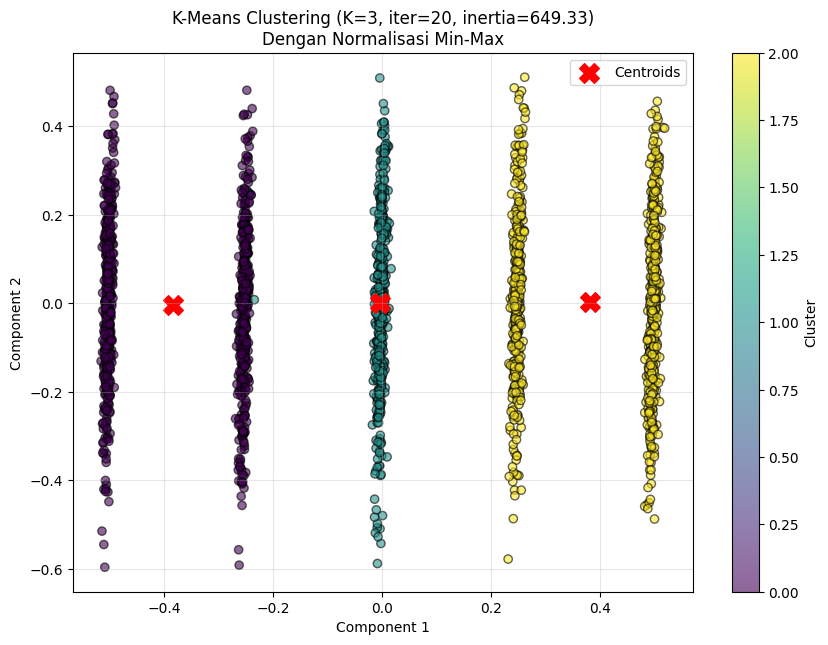


CONTOH SAMPEL DENGAN CLUSTER
 Sample_Index  Cluster     Fitur_ringkasan
            0        0 [30.   1.   1.6]...
            1        0 [25.   2.   2.4]...
            2        2 [32.   5.   0.5]...
            3        2    [39.  4.  3.]...
            4        1 [25.   3.   3.9]...
            5        1 [25.   3.   4.6]...
            6        0 [39.   1.   0.7]...
            7        0 [33.   2.   1.5]...
            8        0 [23.   2.   4.4]...
            9        0 [31.   1.   2.3]...

RINGKASAN EKSEKUSI
✓ Dataset: Clustering.csv
✓ Total sampel: 2000
✓ Jumlah fitur yang digunakan: 15
✓ Fitur: ['age', 'platforms_used_count', 'daily_usage_hours', 'sessions_per_day', 'avg_session_duration_min', 'followers_count', 'following_count', 'posts_per_week', 'likes_given_per_day', 'comments_per_day', 'shares_per_day', 'dms_sent_per_day', 'ad_click_rate', 'monthly_spend_via_social_usd', 'self_reported_mental_health_score']
✓ Preprocessing: Normalisasi Min-Max (skala [0,1])
✓ Metode: K-

In [ ]:
# ============================================
# IMPLEMENTASI K-MEANS CLUSTERING DENGAN MIN-MAX NORMALIZATION
# ============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset
print("="*50)
print("LOADING DATASET")
print("="*50)
df = pd.read_csv('Clustering.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah sampel: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\n5 Data pertama:")
print(df.head())

# Tampilkan nama kolom
print(f"\nNama-nama kolom dalam dataset:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. '{col}'")

# 3. Persiapan data - Fitur yang digunakan
print("\n" + "="*50)
print("PERSIAPAN DATA")
print("="*50)

# Gunakan semua kolom numerik sebagai fitur
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_columns) == 0:
    raise ValueError("Tidak ada kolom numerik untuk clustering!")

print(f"Kolom numerik yang tersedia: {numeric_columns}")
print(f"Menggunakan semua kolom numerik sebagai fitur (total {len(numeric_columns)} fitur)")

X_raw = df[numeric_columns].values  # Data asli sebelum normalisasi
print(f"Shape data fitur (sebelum normalisasi): {X_raw.shape}")

# 4. Normalisasi Min-Max
print("\n" + "="*50)
print("NORMALISASI MIN-MAX")
print("="*50)

scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)  # Data setelah normalisasi

print("Normalisasi Min-Max berhasil dilakukan!")
print(f"Rentang nilai setelah normalisasi: [{X.min():.2f} - {X.max():.2f}]")
print(f"Setiap fitur diskalakan ke rentang [0, 1]")

# Tampilkan perbandingan beberapa nilai sebelum dan sesudah normalisasi
print("\nContoh perbandingan (5 sampel pertama):")
for i in range(min(5, X_raw.shape[0])):
    print(f"  Sampel {i}: sebelum = {X_raw[i]}, sesudah = {X[i]}")

# 5. Inisialisasi centroid dari baris tertentu (0, 1, 2) pada DATA YANG SUDAH DINORMALISASI
print("\n" + "="*50)
print("INISIALISASI CENTROID")
print("="*50)

# Indeks baris untuk centroid (0-based)
centroid_indices = [0, 1, 2]

# Validasi indeks
max_index = X.shape[0] - 1
for idx in centroid_indices:
    if idx > max_index:
        raise ValueError(f"Indeks {idx} melebihi jumlah baris dataset ({X.shape[0]})")

# Ambil data dari baris tersebut sebagai centroid awal (setelah normalisasi)
initial_centroids = X[centroid_indices, :]
print(f"Centroid awal diambil dari baris ke-{centroid_indices[0]}, ke-{centroid_indices[1]}, ke-{centroid_indices[2]}")
print(f"Shape centroid awal: {initial_centroids.shape}")
print(f"Nilai centroid awal (setelah normalisasi):\n{initial_centroids}")

# 6. Implementasi K-Means
print("\n" + "="*50)
print("IMPLEMENTASI K-MEANS")
print("="*50)

# Konfigurasi K-Means
kmeans = KMeans(
    n_clusters=3,
    init=initial_centroids,
    n_init=1,           # Hanya 1 kali inisialisasi (karena centroid sudah ditentukan)
    max_iter=30,        # Maksimum iterasi = 30
    random_state=42,
    algorithm='lloyd'   # Algoritma standard (Euclidean)
)

print("Konfigurasi K-Means:")
print(f"  - Jumlah cluster (K) = 3")
print(f"  - Inisialisasi centroid = baris ke-0, 1, 2 (pada data ternormalisasi)")
print(f"  - Metrik jarak = Euclidean")
print(f"  - Maksimum iterasi = 30")
print(f"  - Normalisasi = Min-Max (diterapkan sebelum clustering)")

# Latih model
print("\nMelatih model K-Means...")
kmeans.fit(X)
print("Model berhasil dilatih!")

# 7. Hasil clustering
print("\n" + "="*50)
print("HASIL CLUSTERING")
print("="*50)

# Label cluster untuk setiap sampel
cluster_labels = kmeans.labels_
print(f"Jumlah sampel per cluster:")
for i in range(3):
    count = np.sum(cluster_labels == i)
    print(f"  Cluster {i}: {count} sampel")

# Centroid akhir (dalam skala ternormalisasi)
final_centroids_scaled = kmeans.cluster_centers_
print(f"\nCentroid akhir (dalam skala ternormalisasi):")
for i, centroid in enumerate(final_centroids_scaled):
    print(f"  Cluster {i}: {centroid}")

# Transformasi centroid kembali ke skala asli (untuk interpretasi)
final_centroids_original = scaler.inverse_transform(final_centroids_scaled)
print(f"\nCentroid akhir (dalam skala asli):")
for i, centroid in enumerate(final_centroids_original):
    print(f"  Cluster {i}: {centroid}")

# 8. Informasi iterasi
print(f"\nJumlah iterasi yang dilakukan: {kmeans.n_iter_}")
print(f"Toleransi konvergensi: {kmeans.tol}")

# 9. Evaluasi internal (Inertia / Within-Cluster Sum of Squares)
print("\n" + "="*50)
print("EVALUASI INTERNAL")
print("="*50)
inertia = kmeans.inertia_
print(f"Inertia (WCSS): {inertia:.4f}")

# Silhouette Score (jika lebih dari 1 cluster dan sampel cukup)
if X.shape[0] > 3:
    from sklearn.metrics import silhouette_score
    sil_score = silhouette_score(X, cluster_labels, metric='euclidean')
    print(f"Silhouette Score: {sil_score:.4f}")
    print("  - Range: -1 (buruk) hingga 1 (baik)")
    if sil_score > 0.5:
        print("  → Struktur cluster baik")
    elif sil_score > 0.2:
        print("  → Struktur cluster cukup")
    else:
        print("  → Struktur cluster lemah")
else:
    print("Silhouette Score tidak dihitung karena jumlah sampel terlalu sedikit.")

# 10. Visualisasi (opsional, jika fitur 2D atau 3D)
try:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    # Jika fitur > 2 dimensi, reduksi dengan PCA untuk visualisasi
    if X.shape[1] > 2:
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X)
        explained_var = pca.explained_variance_ratio_
        print(f"\nPCA: Variance explained by 2 components: {explained_var[0]:.2%} + {explained_var[1]:.2%}")
    else:
        X_pca = X

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, edgecolors='k')

    # Centroid dalam ruang PCA
    if X.shape[1] > 2:
        centroids_pca = pca.transform(kmeans.cluster_centers_)
    else:
        centroids_pca = kmeans.cluster_centers_

    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='X', s=200, c='red', label='Centroids')
    plt.title(f'K-Means Clustering (K=3, iter={kmeans.n_iter_}, inertia={inertia:.2f})\nDengan Normalisasi Min-Max')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar(scatter, label='Cluster')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print(f"(Visualisasi tidak dapat ditampilkan: {e})")

# 11. Tampilkan beberapa sampel beserta clusternya (dalam skala asli)
print("\n" + "="*50)
print("CONTOH SAMPEL DENGAN CLUSTER")
print("="*50)
n_display = min(10, X.shape[0])
sample_df = pd.DataFrame({
    'Sample_Index': range(n_display),
    'Cluster': cluster_labels[:n_display]
})
# Tambahkan nilai fitur asli (sebelum normalisasi) jika tidak terlalu banyak
if X_raw.shape[1] <= 5:
    for i in range(X_raw.shape[1]):
        sample_df[f'Fitur_{i+1}_asli'] = X_raw[:n_display, i]
else:
    sample_df['Fitur_ringkasan'] = [f"{X_raw[i, :3]}..." for i in range(n_display)]
print(sample_df.to_string(index=False))

# 12. Ringkasan eksekusi
print("\n" + "="*50)
print("RINGKASAN EKSEKUSI")
print("="*50)
print(f"✓ Dataset: Clustering.csv")
print(f"✓ Total sampel: {X.shape[0]}")
print(f"✓ Jumlah fitur yang digunakan: {X.shape[1]}")
print(f"✓ Fitur: {numeric_columns}")
print(f"✓ Preprocessing: Normalisasi Min-Max (skala [0,1])")
print(f"✓ Metode: K-Means")
print(f"  - Jumlah cluster (K) = 3")
print(f"  - Inisialisasi centroid = baris ke-0,1,2 (pada data ternormalisasi)")
print(f"  - Metrik jarak = Euclidean")
print(f"  - Maksimum iterasi = 30")
print(f"✓ Hasil:")
print(f"  - Jumlah iterasi aktual: {kmeans.n_iter_}")
print(f"  - Inertia (WCSS): {inertia:.4f}")
if 'sil_score' in locals():
    print(f"  - Silhouette Score: {sil_score:.4f}")
print("="*50)

**Model Naive Bayes**

LOADING DATASET
Dataset berhasil dimuat!
Jumlah sampel: 50000
Jumlah kolom: 16

5 Data pertama:
   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_

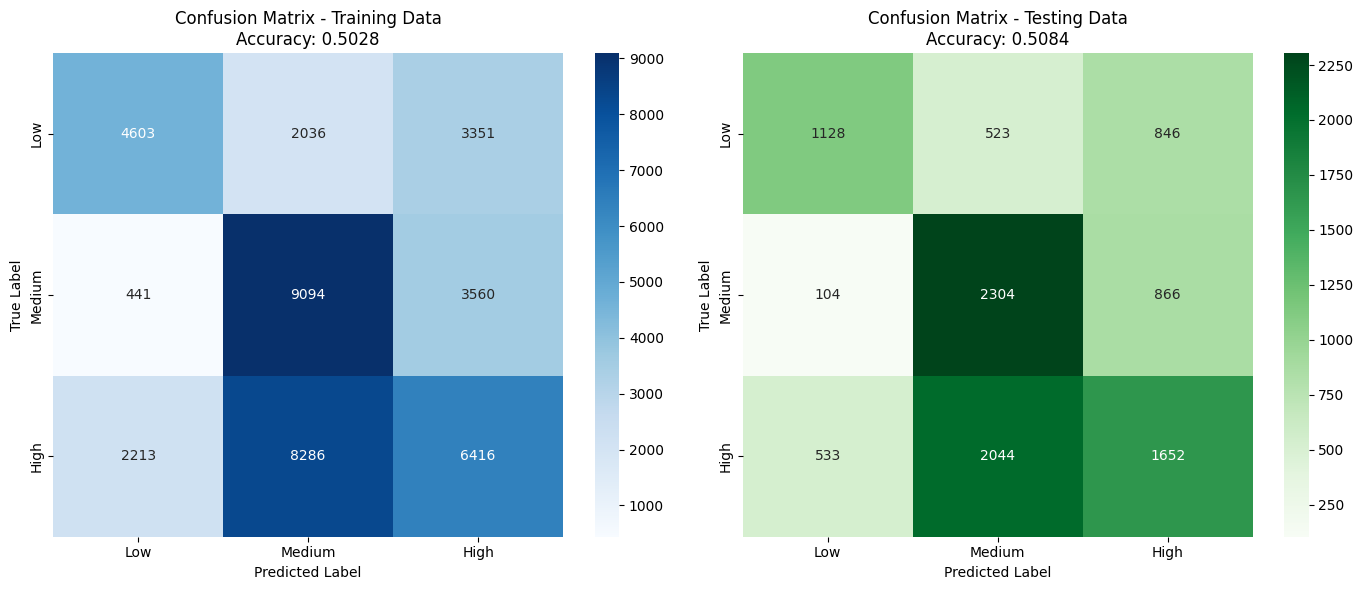


CONTOH PREDIKSI DENGAN PROBABILITAS

Sampel ke-1:
  - Label asli: Medium
  - Label prediksi: Medium
  - Confidence: 62.97%
  - Probabilitas per kelas:
      High: 0.1429
      Low: 0.2274
      Medium: 0.6297
  - Status: ✓ BENAR

Sampel ke-2:
  - Label asli: Medium
  - Label prediksi: Low
  - Confidence: 68.16%
  - Probabilitas per kelas:
      High: 0.0122
      Low: 0.6816
      Medium: 0.3062
  - Status: ✗ SALAH

Sampel ke-3:
  - Label asli: Low
  - Label prediksi: Low
  - Confidence: 50.70%
  - Probabilitas per kelas:
      High: 0.0493
      Low: 0.5070
      Medium: 0.4437
  - Status: ✓ BENAR

Sampel ke-4:
  - Label asli: Medium
  - Label prediksi: Low
  - Confidence: 62.95%
  - Probabilitas per kelas:
      High: 0.0299
      Low: 0.6295
      Medium: 0.3407
  - Status: ✗ SALAH

Sampel ke-5:
  - Label asli: High
  - Label prediksi: High
  - Confidence: 99.82%
  - Probabilitas per kelas:
      High: 0.9982
      Low: 0.0000
      Medium: 0.0018
  - Status: ✓ BENAR

RINGKASAN EKS

In [ ]:
# ============================================
# IMPLEMENTASI NAIVE BAYES CLASSIFIER
# UNTUK KLASIFIKASI BURNOUT RISK LEVEL
# ============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset
print("="*50)
print("LOADING DATASET")
print("="*50)
df = pd.read_csv('Klasifikasi.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah sampel: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\n5 Data pertama:")
print(df.head())

# 3. Persiapan data - Pisahkan fitur dan label
print("\n" + "="*50)
print("PERSIAPAN DATA")
print("="*50)

label_column = 'Burnout_Risk_Level'

# Tentukan kolom yang akan digunakan sebagai fitur
# Semua kolom kecuali 'Student_ID' dan label_column
fitur_columns = [col for col in df.columns if col not in ['Student_ID', label_column]]
print(f"Fitur yang digunakan: {fitur_columns}")
print(f"Jumlah fitur: {len(fitur_columns)}")

X = df[fitur_columns]
y = df[label_column]

# Identifikasi kolom numerik dan kategorikal
numeric_columns = X.select_dtypes(include=['int64', 'float64', 'bool']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

print(f"\nFitur numerik: {list(numeric_columns)}")
print(f"Fitur kategorikal: {list(categorical_columns)}")

# 4. Encoding untuk kolom kategorikal
print("\n" + "="*50)
print("ENCODING DATA KATEGORIKAL")
print("="*50)

X_processed = X.copy()
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col])
    label_encoders[col] = le
    print(f"  - {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\nSetelah encoding (5 data pertama):")
print(X_processed.head())

# 5. Split data (Train/Test = 80/20)
print("\n" + "="*50)
print("SPLIT DATA TRAIN/TEST")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Ukuran data training: {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Ukuran data testing: {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nDistribusi kelas training:")
print(y_train.value_counts())
print(f"\nDistribusi kelas testing:")
print(y_test.value_counts())

# 6. Implementasi Naive Bayes (GaussianNB)
print("\n" + "="*50)
print("IMPLEMENTASI NAIVE BAYES")
print("="*50)

nb_model = GaussianNB()
print("Menggunakan Gaussian Naive Bayes (cocok untuk fitur kontinu/numerik)")
print("Konfigurasi Naive Bayes:")
print("  - Asumsi distribusi data: Gaussian (Normal)")
print("  - Prior kelas: diestimasi dari data training")
print("  - Varians smoothing: default (1e-9)")

# Latih model
print("\nMelatih model Naive Bayes...")
nb_model.fit(X_train, y_train)
print("Model berhasil dilatih!")

# 7. Evaluasi model pada TRAINING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TRAINING DATA")
print("="*50)

y_train_pred = nb_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"\nAKURASI TRAINING: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {train_precision:.4f}")
print(f"RECALL (weighted): {train_recall:.4f}")
print(f"F1-SCORE (weighted): {train_f1:.4f}")

print("\nCLASSIFICATION REPORT - TRAINING DATA:")
print("-"*50)
print(classification_report(y_train, y_train_pred))

print("\nCONFUSION MATRIX - TRAINING DATA:")
print("-"*50)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)

# 8. Evaluasi model pada TESTING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TESTING DATA")
print("="*50)

y_test_pred = nb_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAKURASI TESTING: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {test_precision:.4f}")
print(f"RECALL (weighted): {test_recall:.4f}")
print(f"F1-SCORE (weighted): {test_f1:.4f}")

print("\nCLASSIFICATION REPORT - TESTING DATA:")
print("-"*50)
print(classification_report(y_test, y_test_pred))

print("\nCONFUSION MATRIX - TESTING DATA:")
print("-"*50)
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

# 9. Perbandingan metrik Training vs Testing
print("\n" + "="*50)
print("PERBANDINGAN METRIK TRAINING VS TESTING")
print("="*50)

print("\n{:<20} {:<15} {:<15} {:<15}".format("Metrik", "Training", "Testing", "Selisih"))
print("-"*65)
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Accuracy", train_accuracy, test_accuracy, test_accuracy - train_accuracy))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Precision", train_precision, test_precision, test_precision - train_precision))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Recall", train_recall, test_recall, test_recall - train_recall))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("F1-Score", train_f1, test_f1, test_f1 - train_f1))

# Deteksi overfitting/underfitting
print("\nANALISIS PERFORMANCE:")
print("-"*50)
diff_accuracy = abs(test_accuracy - train_accuracy)
if diff_accuracy < 0.05:
    print(f"✓ Selisih akurasi kecil ({diff_accuracy:.4f}) - Model baik (tidak overfitting)")
elif test_accuracy < train_accuracy and diff_accuracy > 0.1:
    print(f"⚠ Selisih akurasi cukup besar ({diff_accuracy:.4f}) - Mungkin terjadi overfitting")
else:
    print(f"ℹ Selisih akurasi: {diff_accuracy:.4f}")

# 10. Visualisasi Confusion Matrix (opsional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - Training Data\nAccuracy: {train_accuracy:.4f}')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[1])
    axes[1].set_title(f'Confusion Matrix - Testing Data\nAccuracy: {test_accuracy:.4f}')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"(Visualisasi tidak dapat ditampilkan: {e})")

# 11. Analisis probabilitas untuk beberapa sampel
print("\n" + "="*50)
print("CONTOH PREDIKSI DENGAN PROBABILITAS")
print("="*50)

n_samples = min(5, len(X_test))
for i in range(n_samples):
    sample = X_test.iloc[i:i+1]
    true_label = y_test.iloc[i]
    pred_label = nb_model.predict(sample)[0]
    proba = nb_model.predict_proba(sample)[0]
    max_proba = np.max(proba)

    print(f"\nSampel ke-{i+1}:")
    print(f"  - Label asli: {true_label}")
    print(f"  - Label prediksi: {pred_label}")
    print(f"  - Confidence: {max_proba:.2%}")
    print(f"  - Probabilitas per kelas:")
    for j, kelas in enumerate(nb_model.classes_):
        print(f"      {kelas}: {proba[j]:.4f}")
    print(f"  - Status: {'✓ BENAR' if true_label == pred_label else '✗ SALAH'}")

# 12. Ringkasan eksekusi
print("\n" + "="*50)
print("RINGKASAN EKSEKUSI")
print("="*50)
print(f"✓ Dataset: Klasifikasi.csv")
print(f"✓ Total sampel: {df.shape[0]}")
print(f"✓ Fitur yang digunakan: {len(fitur_columns)} fitur (semua kecuali Student_ID dan target)")
print(f"✓ Kolom label: {label_column}")
print(f"✓ Preprocessing: Label Encoding untuk fitur kategorikal")
print(f"✓ Split data: 80% training ({X_train.shape[0]}), 20% testing ({X_test.shape[0]}) dengan seed 42")
print(f"✓ Model: Gaussian Naive Bayes")
print(f"\n✓ HASIL AKHIR (Naive Bayes):")
print(f"  - Akurasi Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  - Akurasi Testing : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Selisih: {abs(test_accuracy - train_accuracy):.4f}")
print("="*50)

# 13. Informasi tambahan untuk referensi
print("\n" + "="*50)
print("INFORMASI TAMBAHAN")
print("="*50)
print("Fitur kategorikal yang telah di-encode:")
for col, le in label_encoders.items():
    print(f"  {col}: {list(le.classes_)}")
print("\nCatatan tentang Gaussian Naive Bayes:")
print("  - Mengasumsikan fitur independen dan berdistribusi normal")
print("  - Cocok untuk data numerik kontinu")
print("  - Fitur kategorikal telah di-encode ke numerik")
print("  - Tidak memerlukan normalisasi karena bekerja dengan distribusi")

**Model Apriori**

In [2]:
# ============================================
# IMPLEMENTASI APRIORI UNTUK MARKET BASKET ANALYSIS
# ============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from itertools import combinations, chain
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset (Supermarket - 10 transaksi)
print("="*50)
print("LOADING DATASET")
print("="*50)

# Dataset sesuai permintaan
dataset = {
    'T001': ['Roti', 'Susu', 'Mentega'],
    'T002': ['Roti', 'Susu'],
    'T003': ['Susu', 'Popok', 'Bir', 'Telur'],
    'T004': ['Roti', 'Mentega', 'Bir'],
    'T005': ['Roti', 'Susu', 'Popok', 'Bir'],
    'T006': ['Roti', 'Susu', 'Mentega', 'Bir'],
    'T007': ['Susu', 'Popok', 'Bir'],
    'T008': ['Roti', 'Susu', 'Popok'],
    'T009': ['Roti', 'Mentega'],
    'T010': ['Susu', 'Popok', 'Telur']
}

transactions = list(dataset.values())
tid_list = list(dataset.keys())
n_transactions = len(transactions)

print(f"Jumlah transaksi: {n_transactions}")
print(f"Transaksi (TID dan items):")
for tid, items in dataset.items():
    print(f"  {tid}: {items}")

# 3. Konfigurasi Apriori
print("\n" + "="*50)
print("KONFIGURASI APRIORI")
print("="*50)

min_support = 0.3   # 30%
min_confidence = 0.6  # 60%
max_itemset_length = 3  # K maksimal = 3
# LCG 42 tidak digunakan dalam implementasi standar, hanya sebagai seed jika ada random

print(f"Minimum Support: {min_support*100}%")
print(f"Minimum Confidence: {min_confidence*100}%")
print(f"Maksimal Panjang Itemset (K): {max_itemset_length}")

# 4. Fungsi-fungsi Apriori
def get_frequent_itemsets(transactions, min_support, max_length):
    """
    Menemukan frequent itemsets menggunakan algoritma Apriori.
    Returns dictionary: itemset -> support (count)
    """
    n = len(transactions)
    min_support_count = min_support * n

    # Inisialisasi itemset 1-itemset
    item_counts = Counter()
    for trans in transactions:
        for item in trans:
            item_counts[item] += 1

    # Filter itemset 1 dengan support >= min_support_count
    freq_itemsets = {}
    for item, count in item_counts.items():
        if count >= min_support_count:
            freq_itemsets[(item,)] = count

    # Hasil akhir
    all_freq_itemsets = freq_itemsets.copy()

    # Iterasi untuk itemset dengan panjang > 1
    k = 2
    prev_itemsets = list(freq_itemsets.keys())

    while k <= max_length and prev_itemsets:
        # Generate candidate itemsets ukuran k
        candidates = set()
        for i in range(len(prev_itemsets)):
            for j in range(i+1, len(prev_itemsets)):
                # Gabungkan dua itemset jika (k-2) pertama sama
                set1 = set(prev_itemsets[i])
                set2 = set(prev_itemsets[j])
                if len(set1.union(set2)) == k:
                    # Urutkan untuk konsistensi
                    candidate = tuple(sorted(set1.union(set2)))
                    candidates.add(candidate)

        # Hitung support untuk setiap candidate
        candidate_counts = Counter()
        for trans in transactions:
            trans_set = set(trans)
            for cand in candidates:
                if set(cand).issubset(trans_set):
                    candidate_counts[cand] += 1

        # Filter berdasarkan min_support
        new_freq = {}
        for cand, count in candidate_counts.items():
            if count >= min_support_count:
                new_freq[cand] = count

        # Tambahkan ke hasil
        all_freq_itemsets.update(new_freq)
        prev_itemsets = list(new_freq.keys())
        k += 1

    return all_freq_itemsets

def generate_association_rules(freq_itemsets, transactions, min_confidence):
    """
    Menghasilkan association rules dari frequent itemsets.
    Returns list of (antecedent, consequent, support, confidence)
    """
    n = len(transactions)
    rules = []

    for itemset, count in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        support_itemset = count / n

        # Generate semua subset non-kosong sebagai antecedent
        itemset_list = list(itemset)
        for r in range(1, len(itemset_list)):
            for antecedent in combinations(itemset_list, r):
                antecedent = tuple(sorted(antecedent))
                consequent = tuple(sorted(set(itemset_list) - set(antecedent)))

                # Hitung support antecedent
                support_ant = freq_itemsets.get(antecedent, 0) / n
                if support_ant == 0:
                    continue

                confidence = support_itemset / support_ant

                if confidence >= min_confidence:
                    rules.append({
                        'antecedent': antecedent,
                        'consequent': consequent,
                        'support': support_itemset,
                        'confidence': confidence,
                        'lift': support_itemset / (support_ant * (freq_itemsets.get(consequent, 0) / n)) if freq_itemsets.get(consequent, 0) > 0 else 0
                    })

    return rules

# 5. Jalankan Apriori
print("\n" + "="*50)
print("PROSES APRIORI")
print("="*50)

# Hitung frequent itemsets
freq_itemsets = get_frequent_itemsets(transactions, min_support, max_itemset_length)

# Generate association rules
rules = generate_association_rules(freq_itemsets, transactions, min_confidence)

# 6. Tampilkan Frequent Itemsets
print("\n" + "="*50)
print("FREQUENT ITEMSETS")
print("="*50)
print(f"{'Itemset':<30} {'Support Count':<15} {'Support (%)':<12}")
print("-"*57)
for itemset, count in sorted(freq_itemsets.items(), key=lambda x: len(x[0])):
    support_pct = (count / n_transactions) * 100
    print(f"{str(itemset):<30} {count:<15} {support_pct:.2f}%")

# 7. Tampilkan Association Rules
print("\n" + "="*50)
print("ASSOCIATION RULES")
print("="*50)
if rules:
    print(f"{'Rule':<40} {'Support (%)':<12} {'Confidence (%)':<16} {'Lift':<8}")
    print("-"*76)
    for rule in rules:
        ant = ' + '.join(rule['antecedent'])
        cons = ' + '.join(rule['consequent'])
        rule_str = f"{ant} → {cons}"
        support_pct = rule['support'] * 100
        confidence_pct = rule['confidence'] * 100
        lift = rule['lift']
        print(f"{rule_str:<40} {support_pct:<12.2f} {confidence_pct:<16.2f} {lift:<8.2f}")
else:
    print("Tidak ada association rules yang memenuhi minimum confidence.")

# 8. Ringkasan
print("\n" + "="*50)
print("RINGKASAN EKSEKUSI")
print("="*50)
print(f"✓ Jumlah transaksi: {n_transactions}")
print(f"✓ Minimum support: {min_support*100}% ({min_support * n_transactions:.0f} transaksi)")
print(f"✓ Minimum confidence: {min_confidence*100}%")
print(f"✓ Maksimal panjang itemset: {max_itemset_length}")
print(f"✓ Jumlah frequent itemsets: {len(freq_itemsets)}")
print(f"✓ Jumlah association rules: {len(rules)}")
print("="*50)

LOADING DATASET
Jumlah transaksi: 10
Transaksi (TID dan items):
  T001: ['Roti', 'Susu', 'Mentega']
  T002: ['Roti', 'Susu']
  T003: ['Susu', 'Popok', 'Bir', 'Telur']
  T004: ['Roti', 'Mentega', 'Bir']
  T005: ['Roti', 'Susu', 'Popok', 'Bir']
  T006: ['Roti', 'Susu', 'Mentega', 'Bir']
  T007: ['Susu', 'Popok', 'Bir']
  T008: ['Roti', 'Susu', 'Popok']
  T009: ['Roti', 'Mentega']
  T010: ['Susu', 'Popok', 'Telur']

KONFIGURASI APRIORI
Minimum Support: 30.0%
Minimum Confidence: 60.0%
Maksimal Panjang Itemset (K): 3

PROSES APRIORI

FREQUENT ITEMSETS
Itemset                        Support Count   Support (%) 
---------------------------------------------------------
('Roti',)                      7               70.00%
('Susu',)                      8               80.00%
('Mentega',)                   4               40.00%
('Popok',)                     5               50.00%
('Bir',)                       5               50.00%
('Mentega', 'Roti')            4               40.00%
('Rot

**Model C.45**

LOADING DATASET
Dataset berhasil dimuat!
Jumlah sampel: 50000
Jumlah kolom: 16

5 Data pertama:
   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0               23.31       Copywriting/Drafting                 Beginner   
1                1.12                   Ideation                 Advanced   
2               21.26        Summarizing_Reading                 Beginner   
3                1.82       Copywriting/Drafting             Intermediate   
4                9.29  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_

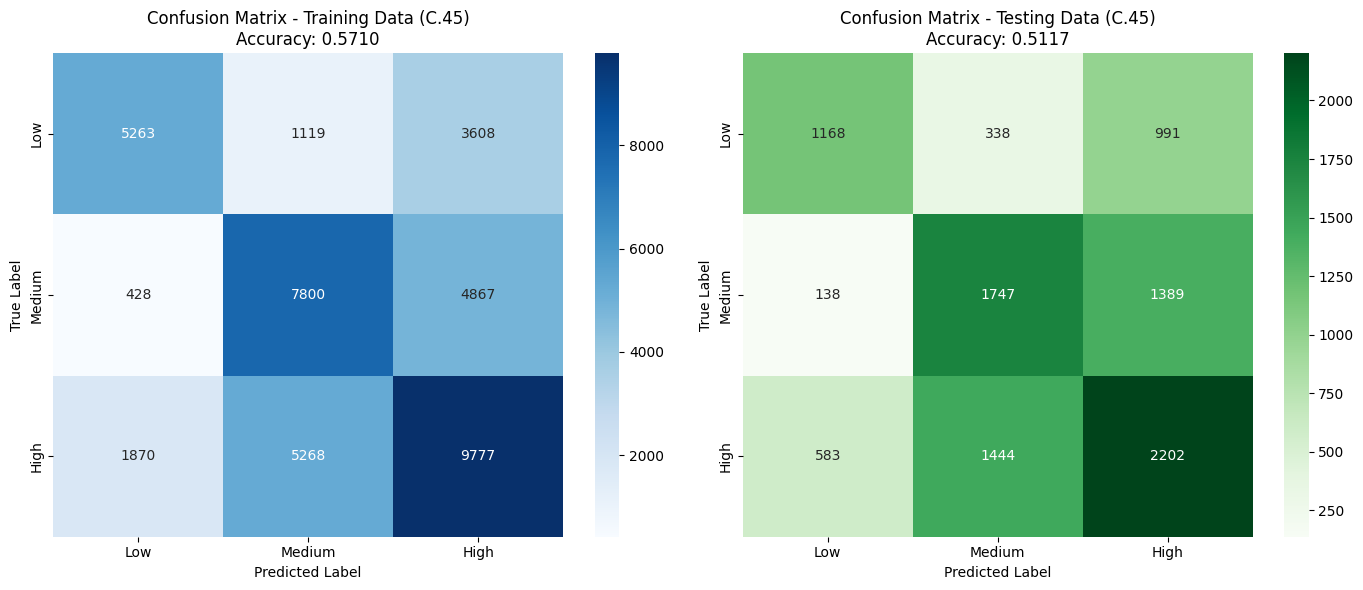


ANALISIS AKURASI PER KELAS

Kelas        Akurasi Training     Akurasi Testing     
-------------------------------------------------------
High         0.5268               0.4678              
Low          0.5956               0.5336              
Medium       0.5780               0.5207              

STRUKTUR POHON KEPUTUSAN
Jumlah node dalam pohon: 1355
Kedalaman pohon: 10
Jumlah leaf: 678
Jumlah fitur yang digunakan: 14 dari 14 fitur

FEATURE IMPORTANCE (URUTAN TERPENTING)

Top 10 fitur terpenting:
                     Fitur  Importance
        Weekly_GenAI_Hours    0.597372
             Year_of_Study    0.079962
          Pre_Semester_GPA    0.061052
   Traditional_Study_Hours    0.058759
         Post_Semester_GPA    0.056278
     Skill_Retention_Score    0.050071
      Institutional_Policy    0.026480
   Perceived_AI_Dependency    0.025951
Anxiety_Level_During_Exams    0.013279
            Tool_Diversity    0.010284

CONTOH PREDIKSI (5 SAMPEL PERTAMA DARI DATA TEST)

Sampel ke

In [ ]:
# ============================================
# IMPLEMENTASI C.45 (DECISION TREE) UNTUK KLASIFIKASI BURNOUT
# DENGAN HANDLING DATA KATEGORIKAL
# FITUR: SEMUA KECUALI TARGET DAN STUDENT_ID
# ============================================

# 1. Import library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset
print("="*50)
print("LOADING DATASET")
print("="*50)
df = pd.read_csv('Klasifikasi.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah sampel: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\n5 Data pertama:")
print(df.head())

# 3. Persiapan data - Pisahkan fitur dan label
print("\n" + "="*50)
print("PERSIAPAN DATA")
print("="*50)

label_column = 'Burnout_Risk_Level'
drop_columns = [label_column, 'Student_ID']  # Kolom yang tidak dijadikan fitur

# Pisahkan fitur (X) dan label (y)
X = df.drop(columns=drop_columns)
y = df[label_column]

# Identifikasi kolom numerik dan kategorikal pada fitur yang tersisa
numeric_columns = X.select_dtypes(include=['int64', 'float64', 'bool']).columns
categorical_columns = X.select_dtypes(include=['object']).columns

print(f"Fitur yang digunakan (semua kecuali Student_ID dan target): {list(X.columns)}")
print(f"Jumlah fitur total: {X.shape[1]}")
print(f"Fitur numerik: {list(numeric_columns)}")
print(f"Fitur kategorikal: {list(categorical_columns)}")

# 4. Encoding untuk kolom kategorikal
print("\n" + "="*50)
print("ENCODING DATA KATEGORIKAL")
print("="*50)

# Copy data untuk preprocessing
X_processed = X.copy()

# Label Encoding untuk setiap kolom kategorikal
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col])
    label_encoders[col] = le
    print(f"  - {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\nSetelah encoding (5 data pertama):")
print(X_processed.head())

# 5. Split data (Train/Test = 80/20 dengan seed 42)
print("\n" + "="*50)
print("SPLIT DATA TRAIN/TEST")
print("="*50)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,  # seed 42
    stratify=y
)

print(f"Ukuran data training: {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Ukuran data testing: {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nDistribusi kelas training:")
print(y_train.value_counts())
print(f"\nDistribusi kelas testing:")
print(y_test.value_counts())

# 6. Implementasi C.45 (Decision Tree) dengan konfigurasi yang diminta
print("\n" + "="*50)
print("IMPLEMENTASI C.45 (DECISION TREE)")
print("="*50)

c45_model = DecisionTreeClassifier(
    criterion='entropy',        # Menggunakan entropy (mendekati Gain Ratio)
    splitter='best',            # Best split (mencari threshold terbaik)
    max_depth=10,               # Maksimum kedalaman pohon = 10
    min_samples_split=3,        # Minimum sampel untuk split = 3
    min_samples_leaf=1,         # Default
    random_state=42             # Untuk reproduksibilitas
)

print("Konfigurasi C.45 (Decision Tree):")
print(f"  - Kriteria Pemilihan Atribut = Gain Ratio (via entropy + best split)")
print(f"  - Maksimum Kedalaman Pohon = 10")
print(f"  - Minimum Sampel untuk Split = 3")
print(f"  - Threshold Atribut Numerik = Midpoint (default behavior)")
print(f"  - Fitur yang digunakan: semua kecuali Student_ID dan target")
print(f"  - Split Data = 80/20 dengan seed 42")
print(f"  - Encoding = Label Encoding untuk fitur kategorikal")

# Latih model
print("\nMelatih model C.45...")
c45_model.fit(X_train, y_train)
print("Model berhasil dilatih!")

# 7. Evaluasi model pada TRAINING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TRAINING DATA")
print("="*50)

y_train_pred = c45_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"\nAKURASI TRAINING: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {train_precision:.4f}")
print(f"RECALL (weighted): {train_recall:.4f}")
print(f"F1-SCORE (weighted): {train_f1:.4f}")

print("\nCLASSIFICATION REPORT - TRAINING DATA:")
print("-"*50)
print(classification_report(y_train, y_train_pred))

print("\nCONFUSION MATRIX - TRAINING DATA:")
print("-"*50)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)

# 8. Evaluasi model pada TESTING DATA
print("\n" + "="*50)
print("EVALUASI MODEL PADA TESTING DATA")
print("="*50)

y_test_pred = c45_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAKURASI TESTING: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"PRECISION (weighted): {test_precision:.4f}")
print(f"RECALL (weighted): {test_recall:.4f}")
print(f"F1-SCORE (weighted): {test_f1:.4f}")

print("\nCLASSIFICATION REPORT - TESTING DATA:")
print("-"*50)
print(classification_report(y_test, y_test_pred))

print("\nCONFUSION MATRIX - TESTING DATA:")
print("-"*50)
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

# 9. Perbandingan metrik Training vs Testing
print("\n" + "="*50)
print("PERBANDINGAN METRIK TRAINING VS TESTING")
print("="*50)

print("\n{:<20} {:<15} {:<15} {:<15}".format("Metrik", "Training", "Testing", "Selisih"))
print("-"*65)
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Accuracy", train_accuracy, test_accuracy, test_accuracy - train_accuracy))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Precision", train_precision, test_precision, test_precision - train_precision))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("Recall", train_recall, test_recall, test_recall - train_recall))
print("{:<20} {:<15.4f} {:<15.4f} {:<+15.4f}".format("F1-Score", train_f1, test_f1, test_f1 - train_f1))

# Deteksi overfitting/underfitting
print("\nANALISIS OVERFITTING:")
print("-"*50)
diff_accuracy = abs(test_accuracy - train_accuracy)
if diff_accuracy < 0.05:
    print(f"✓ Selisih akurasi kecil ({diff_accuracy:.4f}) - Model baik (tidak overfitting)")
elif test_accuracy < train_accuracy and diff_accuracy > 0.1:
    print(f"⚠ Selisih akurasi cukup besar ({diff_accuracy:.4f}) - Mungkin terjadi overfitting")
else:
    print(f"ℹ Selisih akurasi: {diff_accuracy:.4f}")

# 10. Visualisasi Confusion Matrix (opsional)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - Training Data (C.45)\nAccuracy: {train_accuracy:.4f}')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=axes[1])
    axes[1].set_title(f'Confusion Matrix - Testing Data (C.45)\nAccuracy: {test_accuracy:.4f}')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()
except:
    print("(Visualisasi tidak dapat ditampilkan)")

# 11. Analisis akurasi per kelas
print("\n" + "="*50)
print("ANALISIS AKURASI PER KELAS")
print("="*50)

unique_classes = np.unique(y_test)
print("\n{:<12} {:<20} {:<20}".format("Kelas", "Akurasi Training", "Akurasi Testing"))
print("-"*55)

for class_label in unique_classes:
    mask_train = y_train == class_label
    mask_test = y_test == class_label

    class_acc_train = accuracy_score(y_train[mask_train], y_train_pred[mask_train]) if mask_train.any() else 0
    class_acc_test = accuracy_score(y_test[mask_test], y_test_pred[mask_test]) if mask_test.any() else 0

    print("{:<12} {:<20.4f} {:<20.4f}".format(class_label, class_acc_train, class_acc_test))

# 12. Menampilkan struktur pohon keputusan (opsional)
print("\n" + "="*50)
print("STRUKTUR POHON KEPUTUSAN")
print("="*50)

print(f"Jumlah node dalam pohon: {c45_model.tree_.node_count}")
print(f"Kedalaman pohon: {c45_model.get_depth()}")
print(f"Jumlah leaf: {c45_model.get_n_leaves()}")
print(f"Jumlah fitur yang digunakan: {np.sum(c45_model.feature_importances_ > 0)} dari {X_train.shape[1]} fitur")

# 13. Feature Importance (pentingnya fitur)
print("\n" + "="*50)
print("FEATURE IMPORTANCE (URUTAN TERPENTING)")
print("="*50)

feature_importance = pd.DataFrame({
    'Fitur': X_processed.columns,
    'Importance': c45_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 fitur terpenting:")
print(feature_importance.head(10).to_string(index=False))

# 14. Contoh prediksi
print("\n" + "="*50)
print("CONTOH PREDIKSI (5 SAMPEL PERTAMA DARI DATA TEST)")
print("="*50)

n_samples = min(5, len(X_test))
for i in range(n_samples):
    sample = X_test.iloc[i:i+1]
    true_label = y_test.iloc[i]
    pred_label = c45_model.predict(sample)[0]

    proba = c45_model.predict_proba(sample)[0]
    max_proba = np.max(proba)
    leaf_id = c45_model.apply(sample)[0]

    print(f"\nSampel ke-{i+1}:")
    print(f"  - Label asli: {true_label}")
    print(f"  - Label prediksi: {pred_label}")
    print(f"  - Confidence: {max_proba:.2%}")
    print(f"  - Leaf node ID: {leaf_id}")
    print(f"  - Status: {'✓ BENAR' if true_label == pred_label else '✗ SALAH'}")

# 15. Ringkasan eksekusi
print("\n" + "="*50)
print("RINGKASAN EKSEKUSI")
print("="*50)
print(f"✓ Dataset: Klasifikasi.csv")
print(f"✓ Total sampel: {df.shape[0]}")
print(f"✓ Fitur yang digunakan: semua kolom kecuali Student_ID dan {label_column}")
print(f"  - Jumlah fitur: {X.shape[1]}")
print(f"  - Fitur numerik: {len(numeric_columns)}")
print(f"  - Fitur kategorikal: {len(categorical_columns)} (sudah di-encode)")
print(f"✓ Split data: 80% training ({X_train.shape[0]}), 20% testing ({X_test.shape[0]}) dengan seed 42")
print(f"✓ Preprocessing: Label Encoding (tanpa normalisasi)")
print(f"✓ C.45 (Decision Tree) dengan konfigurasi:")
print(f"  - Kriteria: Gain Ratio (entropy + best split)")
print(f"  - Max Depth: 10")
print(f"  - Min Samples Split: 3")
print(f"  - Threshold Numerik: Midpoint")
print(f"\n✓ HASIL AKHIR (C.45):")
print(f"  - Akurasi Training: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  - Akurasi Testing : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Selisih: {abs(test_accuracy - train_accuracy):.4f}")
print("="*50)

# 16. Informasi tambahan untuk referensi
print("\n" + "="*50)
print("INFORMASI TAMBAHAN")
print("="*50)
print("Fitur kategorikal yang telah di-encode:")
for col, le in label_encoders.items():
    print(f"  {col}: {list(le.classes_)}")

print("\nCatatan tentang Gain Ratio di scikit-learn:")
print("  - Scikit-learn tidak memiliki implementasi Gain Ratio langsung")
print("  - Menggunakan criterion='entropy' dengan splitter='best' sebagai pendekatan")
print("  - Gain Ratio = Information Gain / Split Info")
print("  - Dengan max_depth dan min_samples_split yang dibatasi, model tetap terkontrol")